# **BirdCLEF 2025 Data Preprocessing Notebook | MLiP Group 33**

This notebook demonstrates how we can transform audio data into mel-spectrogram data. This transformation is essential for training 2D Convolutional Neural Networks (CNNs) on audio data, as it converts the one-dimensional audio signals into two-dimensional image-like representations.

We also implemented human voice detection and removal, followed silence trimming, ensuring that only animal sounds remain in the final audio clips.

Here is a list of new experiments (features) that were built on top of this baseline notebook:

(this notebook will test just speech removal functionality on the original notebook)

| ID | Experiment                   | Builds on top of experiment ID | Public LB score | Notes               |
|----|-----------------------------|-------------------------------|------------------|---------------------|
| 1  | Baseline                    | /                             | 0.796            |                     |
| 2  | Speech removal              | 1                           | NA               |                     |
| 3  | Silence removal              | 2                             | NA               |                     |
| 4  | Random 5s clip            | 3                   | NA            |                     |
| 5  | Final                       | 4                             | NA               | All steps combined  |




#### Imports

In [1]:
import os
import cv2
import math
import time
import librosa
import pandas as pd
import numpy as np
import torchaudio
import torch
import warnings
from tqdm.notebook import tqdm
import soundfile as sf
import pickle
import IPython.display as ipd

!pip install noisereduce

import noisereduce as nr

warnings.filterwarnings("ignore")

#### Config class

This class holds variables that are used across the notebook. When the `DEBUG_MODE` variable is set to **False**, the entire *train_audio* dataset will be processed. If it's set to **True**, only the first `N_MAX` samples will be processed. This feature is helpful during development for quickly testing your implementation.

**(The Config class was modified by the team - we changed the Mel spectogram parameters to align it with the sampling rate allowed by the Silero VAD library which is used for human speech detection)**

In [2]:
class Config:
 
    DEBUG_MODE = False
    
    OUTPUT_DIR = '/kaggle/working/'
    DATA_ROOT = '/kaggle/input/birdclef-2025'
    FS = 16000
    
    # Mel spectrogram parameters
    N_FFT = 512
    HOP_LENGTH = 256
    N_MELS = 64
    FMIN = 50
    FMAX = 8000
    
    TARGET_DURATION = 5.0
    TARGET_SHAPE = (256, 256)

    # Silero VAD parameters
    sampling_rate = 16000 # or 8000 and nothing else
    
    
    N_MAX = 5 if DEBUG_MODE else None  

config = Config()

In [3]:
print(f"Debug mode: {'ON' if config.DEBUG_MODE else 'OFF'}")
print(f"Max samples to process: {config.N_MAX if config.N_MAX is not None else 'ALL'}")

print("Loading taxonomy data...")
taxonomy_df = pd.read_csv(f'{config.DATA_ROOT}/taxonomy.csv')
species_class_map = dict(zip(taxonomy_df['primary_label'], taxonomy_df['class_name']))

print("Loading training metadata...")
train_df = pd.read_csv(f'{config.DATA_ROOT}/train.csv')

Debug mode: OFF
Max samples to process: ALL
Loading taxonomy data...
Loading training metadata...


In [4]:
label_list = sorted(train_df['primary_label'].unique())
label_id_list = list(range(len(label_list)))
label2id = dict(zip(label_list, label_id_list))
id2label = dict(zip(label_id_list, label_list))

print(f'Found {len(label_list)} unique species')
working_df = train_df[['primary_label', 'rating', 'filename']].copy()
working_df['target'] = working_df.primary_label.map(label2id)
working_df['filepath'] = config.DATA_ROOT + '/train_audio/' + working_df.filename
working_df['samplename'] = working_df.filename.map(lambda x: x.split('/')[0] + '-' + x.split('/')[-1].split('.')[0])
working_df['class'] = working_df.primary_label.map(lambda x: species_class_map.get(x, 'Unknown'))
total_samples = min(len(working_df), config.N_MAX or len(working_df))
print(f'Total samples to process: {total_samples} out of {len(working_df)} available')
print(f'Samples by class:')
print(working_df['class'].value_counts())

Found 206 unique species
Total samples to process: 28564 out of 28564 available
Samples by class:
class
Aves        27648
Amphibia      583
Mammalia      178
Insecta       155
Name: count, dtype: int64


### Human voice detection & removal, voice silence and noise trimming 

The following section includes the code that removes human speech from the audio recordings and then trims the silence.

#### Helper functions

**(TEAM CONTRIBUTION)**

(not used in this version)

In [5]:
def remove_long_silence(audio_data, top_db=30, sr=16000, min_silence_len=1):
    '''
    This function removes silent segments that are longer than the specified duration 
    (min_silence_len) between non-silent audio segments.

    Parameters:
    - audio_data: The input audio data (numpy array).
    - top_db: The threshold for silence (in decibels) below which audio is considered silent.
    - sr: The sample rate of the audio.
    - min_silence_len: The minimum duration of silence (in seconds) that should be kept.

    Returns:
    - cleaned_audio (numpy array) with long silences trimmed
    '''
    intervals = librosa.effects.split(audio_data, top_db=top_db)
    cleaned_audio = []

    for i, (start, end) in enumerate(intervals):
        cleaned_audio.append(audio_data[start:end])

        # Check for silence between current end and next start
        if i < len(intervals) - 1:
            next_start = intervals[i + 1][0]
            silence = audio_data[end:next_start]
            silence_duration = len(silence) / sr

            # Only add silence back if it's shorter than min_silence_len
            if silence_duration < min_silence_len:
                cleaned_audio.append(silence)

    return np.concatenate(cleaned_audio)


#### Initialize `silero-vad` model

In [6]:
torch.set_num_threads(1)
model, (get_speech_timestamps, _, read_audio, _, _) = torch.hub.load(repo_or_dir='snakers4/silero-vad', model='silero_vad')

Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip


**(TEAM CONTRIBUTION)**

In [7]:
def remove_speech_and_silence(fname):
    '''
    This function removes human speech segments from an audio file and trims long periods of silence.

    Parameters:
    - fname (str): The path to the audio file to process.

    Returns:
    - cleaned_audio_wav (numpy array): The processed audio array with speech removed and long silences trimmed.
    
    If no speech is detected, the function leaves the audio unchanged.
    '''
    sampling_rate = 16000
    padding = int(0.1 * sampling_rate)  # Padding for non-speech parts
    
    
    try:
        # Load audio file
        wav, sr = librosa.load(fname, sr=sampling_rate)
    
        # Detect speech segments
        speech_timestamps = get_speech_timestamps(torch.tensor(wav), model, sampling_rate=sampling_rate, threshold=0.9)
    
        # Remove speech segments and pad with silence
        nonspeech = []
        prev_end = 0
        for segment in speech_timestamps:
            start = max(0, segment['start'] - padding)
            end = min(len(wav), segment['end'] + padding)
            nonspeech.append(wav[prev_end:start])
            prev_end = end
        nonspeech.append(wav[prev_end:])  # Append the last non-speech part
    
        # If there is data to concatenate, do it
        if nonspeech:
            wav = np.concatenate(nonspeech)
        else:
            wav = wav
    
        # Trim silence
        cleaned_audio_wav = remove_long_silence(wav)
    
        return cleaned_audio_wav
    
    except Exception as e:
        print(f'Error processing {fname}: {e}')
        return None

Here you can see the result of the `remove_speech_and_silence` function. You can choose an **index** between **0 and 28563**. 

Note: Some clips exceed 5 seconds in length, but later in the notebook, we either extract a random 5-second segment from the cleaned clip or repeat it until it reaches the desired duration.

**(TEAM CONTRIBUTION)**

In [8]:
rec = working_df.iloc[20000] 
fname = f"/kaggle/input/birdclef-2025/train_audio/{rec.filename}"
raw_wav, sr = librosa.load(fname, sr=config.FS)

print("🔊 Raw audio:")
display(ipd.Audio(raw_wav, rate=config.FS))

print("🔊 Processed (cleaned) audio:")
display(ipd.Audio(remove_speech_and_silence(fname), rate=config.FS))

🔊 Raw audio:


🔊 Processed (cleaned) audio:


**(Copied)**

In [9]:
# This function converts an audio clip to mel spectogram
def audio2melspec(audio_data):
    '''
    This function converts an audio clip into a normalized Mel spectrogram.

    Parameters:
    - audio_data (numpy array): The raw audio signal to be converted.

    Returns:
    - mel_spec_norm (numpy array): The normalized Mel spectrogram of the audio clip.
    
    The function first handles any NaN values in the audio data by replacing them with the mean of the signal.
    Then, it computes the Mel spectrogram, converts it to decibels, and normalizes it for further processing.
    '''
    
    if np.isnan(audio_data).any():
        mean_signal = np.nanmean(audio_data)
        audio_data = np.nan_to_num(audio_data, nan=mean_signal)

    mel_spec = librosa.feature.melspectrogram(
        y=audio_data,
        sr=config.FS,
        n_fft=config.N_FFT,
        hop_length=config.HOP_LENGTH,
        n_mels=config.N_MELS,
        fmin=config.FMIN,
        fmax=config.FMAX,
        power=2.0
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)
    
    return mel_spec_norm

#### Actual preprocessing

The following block processes each audio file in the *train_audio* dataset by first removing speech and trimming silence. Since our target is a 5-second audio clip, if the result is shorter than 5 seconds, we repeat the audio until the required duration is met. A **random** 5-second segment is then extracted, converted into a Mel spectrogram, and stored.

**(TEAM CONTRIBUTION - modified from the original notebook)**

In [10]:
print("Starting audio processing...")
print(f"{'DEBUG MODE - Processing only TODO samples' if config.DEBUG_MODE else 'FULL MODE - Processing all samples'}")
start_time = time.time()

all_bird_data = {}
errors = []

np.random.seed(20)


for i, row in tqdm(working_df.iterrows(), total=total_samples):
    if config.N_MAX is not None and i >= config.N_MAX:
        break

    try:
        rec = working_df.iloc[i]
        fname = f'/kaggle/input/birdclef-2025/train_audio/{rec.filename}'

        # Get cleaned audio data
        audio_data = remove_speech_and_silence(fname)

        # Ensure at least target duration
        target_samples = int(config.TARGET_DURATION * config.FS)
        if len(audio_data) < target_samples:
            n_copy = math.ceil(target_samples / len(audio_data))
            audio_data = np.concatenate([audio_data] * n_copy)

        # Get random 5s from cleaned audio
        max_start = len(audio_data) - target_samples
        start_idx = np.random.randint(0, max_start + 1)
        end_idx = start_idx + target_samples
        audio_crop = audio_data[start_idx:end_idx]

        mel_spec = audio2melspec(audio_crop)

        if mel_spec.shape != config.TARGET_SHAPE:
            mel_spec = cv2.resize(mel_spec, config.TARGET_SHAPE, interpolation=cv2.INTER_LINEAR)

        all_bird_data[row.samplename] = mel_spec.astype(np.float32)

    except Exception as e:
        print(f"Error processing {row.filepath}: {e}")
        errors.append((row.filepath, str(e)))

end_time = time.time()
print(f"Processing completed in {end_time - start_time:.2f} seconds")
print(f"Successfully processed {len(all_bird_data)} files out of {total_samples} total")
print(f"Failed to process {len(errors)} files")


Starting audio processing...
FULL MODE - Processing all samples


  0%|          | 0/28564 [00:00<?, ?it/s]

Processing completed in 20859.60 seconds
Successfully processed 28564 files out of 28564 total
Failed to process 0 files


**(Copied)**

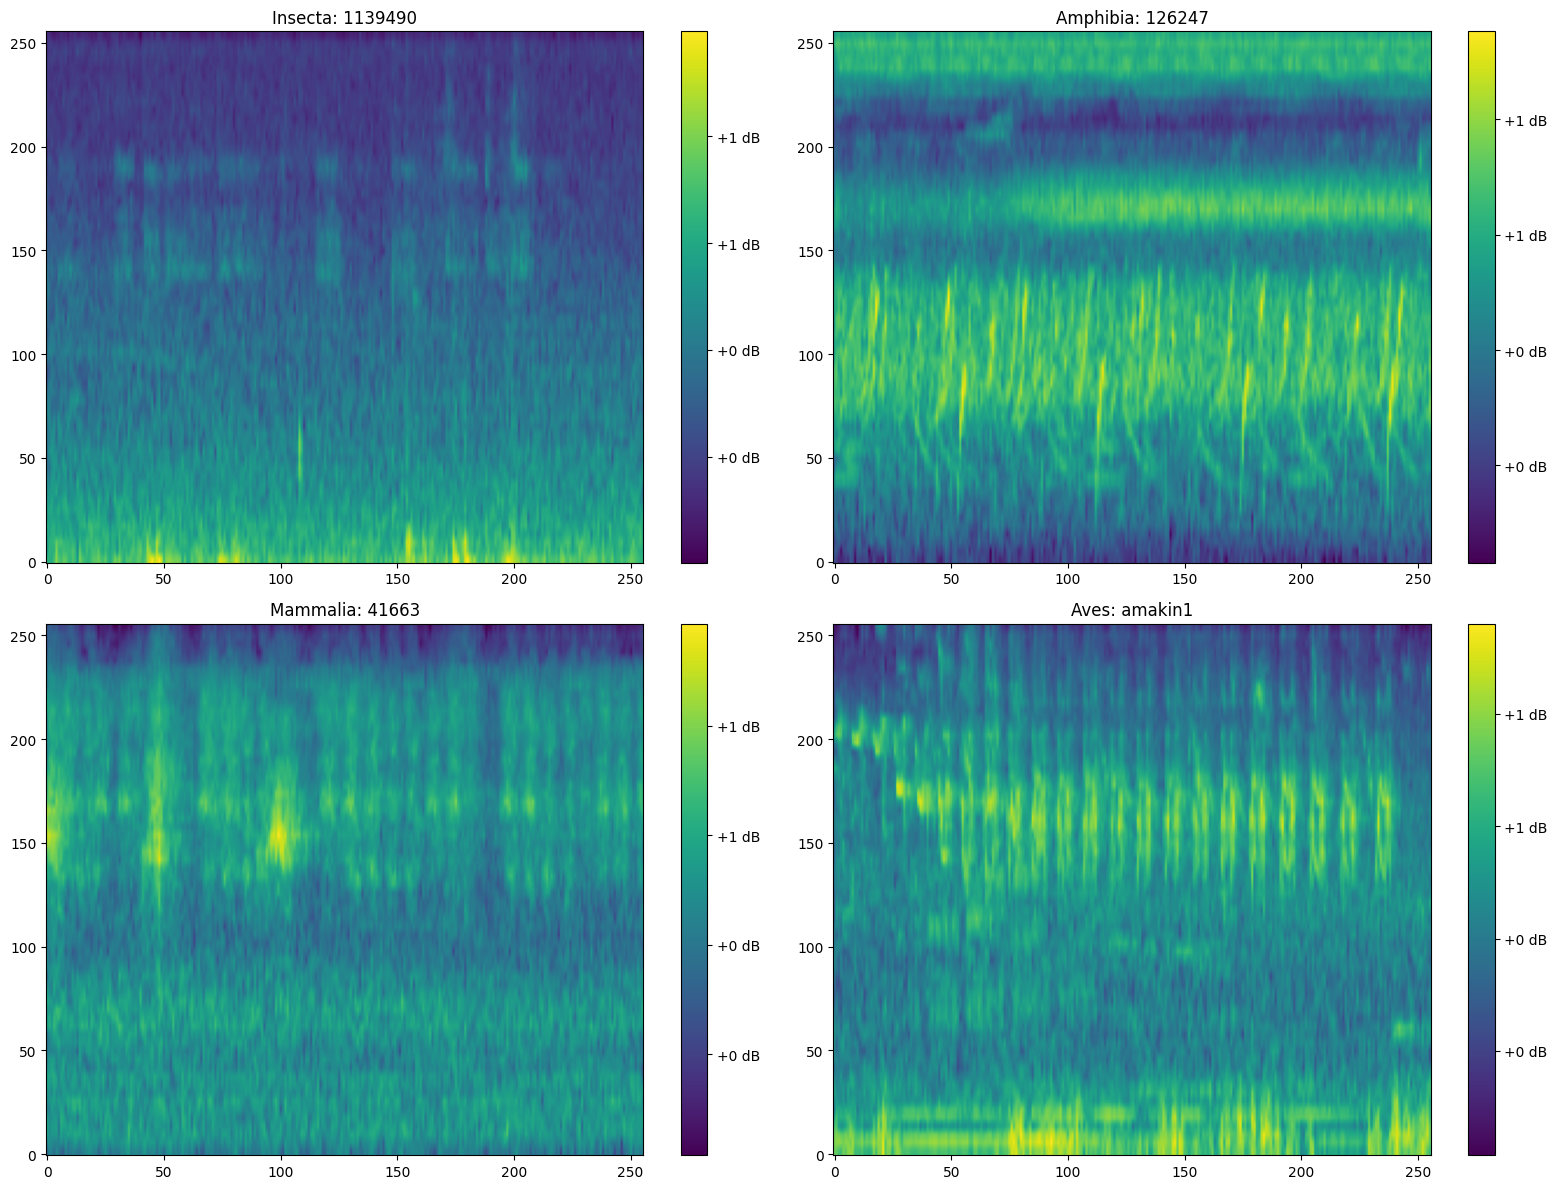

In [11]:
import matplotlib.pyplot as plt

samples = []
displayed_classes = set()

max_samples = min(4, len(all_bird_data))

for i, row in working_df.iterrows():
    if i >= (config.N_MAX or len(working_df)):
        break
        
    if row['samplename'] in all_bird_data:
        if config.DEBUG_MODE:
            if row['class'] not in displayed_classes:
                samples.append((row['samplename'], row['class'], row['primary_label']))
                displayed_classes.add(row['class'])
        else:
            if row['class'] not in displayed_classes:
                samples.append((row['samplename'], row['class'], row['primary_label']))
                displayed_classes.add(row['class'])
        
        if len(samples) >= max_samples:  
            break

if samples:
    plt.figure(figsize=(16, 12))
    
    for i, (samplename, class_name, species) in enumerate(samples):
        plt.subplot(2, 2, i+1)
        plt.imshow(all_bird_data[samplename], aspect='auto', origin='lower', cmap='viridis')
        plt.title(f"{class_name}: {species}")
        plt.colorbar(format='%+2.0f dB')
    
    plt.tight_layout()
    debug_note = "debug_" if config.DEBUG_MODE else ""
    plt.savefig(f'{debug_note}melspec_examples.png')
    plt.show()

In [12]:
output_filename = os.path.join(config.OUTPUT_DIR, "birdclef2025_melspec_test.npy")
np.save(output_filename, all_bird_data)